# Improve Training

In [15]:
## Package Import & Path Setting

from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold

# preprocessing & structure
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# pytorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# other imports
from tqdm.auto import tqdm
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
import time


In [16]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
else:
    print("Using CPU version")

PyTorch version: 2.9.1+cu128
CUDA available: False
Using CPU version


In [17]:
# helper functions
def add_fests(X):
    X = X.copy()
    X['HasCabin'] = X['Cabin'].apply(lambda x: 1 if not pd.isna(x) else 0)
    # X['Cabin_Room_Num'] = X['Cabin'].apply(lambda x: int(x.split()[0][1:]) if pd.notna(x) and x.split()[0][1:] != '' else 0)
    X['Deck'] = X['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else 'Unknown')
    # X['Cabin_Num'] = X['Cabin'].apply(lambda x: len(x.split()) if pd.notna(x) and x != '' else 0)
    X['Company'] = X['SibSp'] + X['Parch']
    X['Alone'] = X['Company'].apply(lambda x: 1 if x == 0 else 0)
    # name
    X['Title'] = X['Name'].apply(lambda x: x.split(',')[1].split()[0])
    incl_title = ['Mr.', 'Miss.', 'Mrs.', 'Master.']
    X['Title'] = X['Title'].apply(lambda x: x if x in incl_title else 'others')
    X['Family'] = X['Name'].apply(lambda x: x.split(',')[0])
    X['Married'] = X['Title'].apply(lambda x: 1 if x=='Mrs.' else 0)
    def deck_class(deck):
        if deck=='Unknown':
            return 'Unknown'
        elif deck in ['C', 'B', 'D', 'E']:
            return 'Common'
        else:
            return 'Rare'
        
    X['Deck'] = X['Deck'].apply(deck_class)
    return X
# baseline model
class LogisticClass(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)

class MLPClass(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)

# training class
class Trainer():
    def __init__(self, model, optimizer, loss_fn, metrics, device=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.hist = {"loss": [], "val_loss": []}
        for name in self.metrics.keys():
            self.hist[name] = []        

    def train(self, train_data, val_data=None, batch_size=64, epochs=5):
        X_tr_np, y_tr_np = train_data
        X_tr = torch.tensor(X_tr_np, dtype=torch.float32)
        y_tr = torch.tensor(y_tr_np, dtype=torch.float32)

        if y_tr.ndim == 1:
            y_tr = y_tr.view(-1, 1)

        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
             
        # for epoch in range(epochs):
        for epoch in tqdm(range(epochs), desc="Training", leave=False):
            self.model.train()
            total_loss = 0
            total_n = 0
            for x, y in train_loader:
                x = x.to(self.device)
                y = y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x).squeeze()
                loss = self.loss_fn(logits, y.squeeze())
                actual_bs = x.size(0)
                total_loss += loss.item() * actual_bs
                total_n += actual_bs
                loss.backward()
                self.optimizer.step()
            self.hist['loss'].append(total_loss / max(total_n, 1))            
            if val_data is not None:
                # validation
                X_val_np, y_val_np = val_data
                
                X_val = torch.tensor(X_val_np, dtype=torch.float32)
                y_val = torch.tensor(y_val_np, dtype=torch.float32)

                if y_val.ndim == 1:
                    y_val = y_val.view(-1, 1)

                val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)             
                self.model.eval()
                val_total_loss = 0
                val_total_n = 0            
                probs_list = []
                with torch.no_grad():
                    for x, y in val_loader:
                        x = x.to(self.device)
                        y = y.to(self.device)
                        logits = self.model(x).squeeze()
                        loss = self.loss_fn(logits, y.squeeze())
                        actual_bs = x.size(0)
                        val_total_loss += loss.item() * actual_bs
                        val_total_n += actual_bs
                        p = torch.sigmoid(logits).detach().cpu().numpy()
                        probs_list.append(p)
                
                self.hist["val_loss"].append(val_total_loss / max(val_total_n, 1))
                probs = np.concatenate(probs_list, axis=0)
                probs_1d = probs.reshape(-1)

                for name, spec in self.metrics.items():
                    if spec["input_type"] == "prob":
                        self.hist[name].append(spec["func"](y_val, probs_1d))
                    elif spec["input_type"] == "label":
                        pred = (probs_1d >= 0.5).astype(int)
                        self.hist[name].append(spec["func"](y_val, pred))
                    else:
                        raise ValueError(f"Unknown input_type for metric '{name}': {spec['input_type']}")
        return self.hist


# cv train
## skf
# cv train
## skf

def perform_cv_baseline(X, y, skf, preprocess_func, device, batch_size=64, epochs=5, lr=1e-2, weight_decay=0.0):
    loss_fn = nn.BCEWithLogitsLoss()
    metrics = {'acc': {'input_type': 'label', 'func': accuracy_score},
               'auc': {'input_type': 'prob', 'func': roc_auc_score}}
    
    acc_scores = []
    auc_scores = []
    dummy_acc_scores = []
    dummy_auc_scores = []
    oof_probs = []
    oof_y_val = []
    oof_dummy_probs = []
    
    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")
    
    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = preprocess_func()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(X_tr_np.shape[1]).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=device)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(device)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
        oof_probs.append(p)
        oof_y_val.append(y_val)
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)
        # dummy model
        dummy_model = DummyClassifier(strategy='most_frequent', random_state=37)
        dummy_model.fit(X_tr_np, y_tr.to_numpy())
        dummy_pred = np.asarray(dummy_model.predict(X_val_np), dtype=int).ravel()
        dummy_prob = np.asarray(dummy_model.predict_proba(X_val_np)[:, 1], dtype=float).ravel()
        oof_dummy_probs.append(dummy_prob)
        dummy_acc_score = accuracy_score(y_val, dummy_pred)
        dummy_acc_scores.append(dummy_acc_score)
        dummy_auc_score = roc_auc_score(y_val, dummy_prob)
        dummy_auc_scores.append(dummy_auc_score)
        tqdm.write(f"Fold {fold} auc score (baseline / dummy): {auc_score:.4f} / {dummy_auc_score:.4f}, acc score: {acc_score:.4f} / {dummy_acc_score:.4f}")
        print(f"Baseline Model AUC/ACC Mean: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f} / {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    
    print(f"Dummy Model AUC/ACC Mean: {np.mean(dummy_auc_scores):.4f} ± {np.std(dummy_auc_scores):.4f} / {np.mean(dummy_acc_scores):.4f} ± {np.std(dummy_acc_scores):.4f}")
    print(f'Baseline Model AUC/ACC Lift: {(np.mean(auc_scores) - np.mean(dummy_auc_scores)):.4f} / {(np.mean(acc_scores) - np.mean(dummy_acc_scores)):.4f}')
    plt.figure()
    oof_probs = np.concatenate(oof_probs)
    oof_y_val = np.concatenate(oof_y_val)
    auc = roc_auc_score(oof_y_val, oof_probs)
    fpr, tpr, thr = roc_curve(oof_y_val, oof_probs)
    plt.plot(fpr, tpr, label=f'Baseline (AUC={auc:.4f})')
    oof_dummy_probs = np.concatenate(oof_dummy_probs)
    dummy_auc = roc_auc_score(oof_y_val, oof_dummy_probs)
    fpr, tpr, thr = roc_curve(oof_y_val, oof_dummy_probs)
    plt.plot(fpr, tpr, label=f'Dummy (AUC={dummy_auc:.4f})')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"OOF ROC Curve")
    plt.legend()
    plt.show()    
    return acc_scores, auc_scores, dummy_acc_scores, dummy_auc_scores, oof_probs, oof_y_val, oof_dummy_probs


# hyperparameter tuning
def cv_eval_fn(params, score_type):
    lr = params['lr']
    weight_decay = params['weight_decay']
    batch_size = params['batch_size']
    epochs = params['epochs']
    loss_fn = nn.BCEWithLogitsLoss()

    metrics = {'acc':{'input_type':'label', 'func':accuracy_score},
            'auc':{'input_type':'prob', 'func':roc_auc_score}
            }
    acc_scores = []
    auc_scores = []

    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")

    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = create_new_preprocess()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(X_tr_np.shape[1]).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=DEVICE)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
   
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)    
    if score_type == 'acc':
        mean_score = np.mean(acc_scores)
        std_score = np.std(acc_scores)
    elif score_type=='auc':
        mean_score = np.mean(auc_scores)
        std_score = np.std(auc_scores)
    else:
        raise ValueError(f"Invalid score_type '{score_type}'. Must be 'acc' or 'auc'.")
    # pbar.postfix(f'Score: {mean_score:.4f}±{std_score:.4f}')
    return mean_score, std_score, model

def log_uniform(rng: np.random.Generator, low: float, high: float) -> float:
    """Sample from log-uniform(low, high)."""
    return float(10 ** rng.uniform(np.log10(low), np.log10(high)))

def sample_params(rng: np.random.Generator) -> dict:
    """Randomly sample a hyperparameter configuration."""
    return {
        "lr": log_uniform(rng, 1e-4, 3e-1),
        "weight_decay": log_uniform(rng, 1e-8, 1e-2),
        "batch_size": int(rng.choice([32, 64, 128])),
        "epochs": 20,  # keep fixed first; tune later if needed
    }

def random_search(rng: np.random.Generator, n_trials: int, cv_eval_fn, score_type):
    """
    cv_eval_fn(params) -> (mean_score, std_score)
    """
    best = None
    best_model = None
    history = []
    pbar = tqdm(range(n_trials), desc="HPO trials")
    for t in pbar:
        params = sample_params(rng)
        mean_score, std_score, model = cv_eval_fn(params, score_type)

        record = {"trial": t, **params, "mean": mean_score, "std": std_score}
        history.append(record)

        # simple selection rule: prefer high mean, break ties by low std
        if (best is None) or (mean_score > best["mean"]) or (
            mean_score == best["mean"] and std_score < best["std"]
        ):
            best = record
            best_model = model
        pbar.set_postfix(best_mean=f"{best['mean']:.4f}", lr=f"{best['lr']:.2e}", wd=f"{best['weight_decay']:.2e}")

    
    return best, history, best_model

# result visualization

def plot_confusion_matrix_and_report(y_true, y_pred, target_names=['not survived', 'survived']):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Not Survived', 'Survived'])
    plt.yticks(tick_marks, ['Not Survived', 'Survived'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=target_names))

def plot_survival_distribution(df, columns_to_plot, y):
    fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 6), constrained_layout=True)
    
    for i, col in enumerate(columns_to_plot):
        ax = axes[i] if len(columns_to_plot) > 1 else axes
        # rows = category values, columns = Survived labels; normalize by row to show distribution per value
        ct = pd.crosstab(df[col], y, normalize='index').fillna(0)
        # nicer column labels
        ct.columns = ['Not Survived (0)', 'Survived (1)'] if set(ct.columns) == {0, 1} else [str(c) for c in ct.columns]
        ct.plot(kind='barh', stacked=True, ax=ax, cmap='tab20', legend=False)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Proportion')
        ax.set_title(f'Distribution of Survival by {col}')
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,  
        loc="center left",
        bbox_to_anchor=(1.01, 0.5)
    )
    
    plt.show()


In [18]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_data_path = DATA_DIR / 'train.csv'
test_data_path = DATA_DIR / 'test.csv'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Data Loading

In [34]:
train_raw_df = pd.read_csv(train_data_path)
test_raw_df = pd.read_csv(test_data_path)

X = train_raw_df.drop('Survived', axis=1)
y = train_raw_df['Survived']
X_test = test_raw_df

## Feature Engineering

* Possible advanced feature extraction:
  1. `Fare`, `Pclass`, `Cabin`: Suggests to room location on the ship => highly connected to survival chance
  2.  Only ~20% of the samples has value in `Cabin`, suggesting a `HasCabin` feature with strong signal.
  3. `SibSp` & `Parch`: Could be combined to a simple feature (`Company` & `Alone`?)
  4. `Prefix` & `Company` combinations (mrs. & parch pair => possible high survival chance)

In [35]:
X['HasCabin'] = X['Cabin'].apply(lambda x: 1 if not pd.isna(x) else 0)
# X['Cabin_Room_Num'] = X['Cabin'].apply(lambda x: int(x.split()[0][1:]) if pd.notna(x) and x.split()[0][1:] != '' else 0)
X['Deck'] = X['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else 'Unknown')
# X['Cabin_Num'] = X['Cabin'].apply(lambda x: len(x.split()) if pd.notna(x) and x != '' else 0)
X['Company'] = X['SibSp'] + X['Parch']
X['Alone'] = X['Company'].apply(lambda x: 1 if x == 0 else 0)

# name
X['Title'] = X['Name'].apply(lambda x: x.split(',')[1].split()[0])
incl_title = ['Mr.', 'Miss.', 'Mrs.', 'Master.']
X['Title'] = X['Title'].apply(lambda x: x if x in incl_title else 'others')
X['Family'] = X['Name'].apply(lambda x: x.split(',')[0])
X['Married'] = X['Title'].apply(lambda x: 1 if x=='Mrs.' else 0)


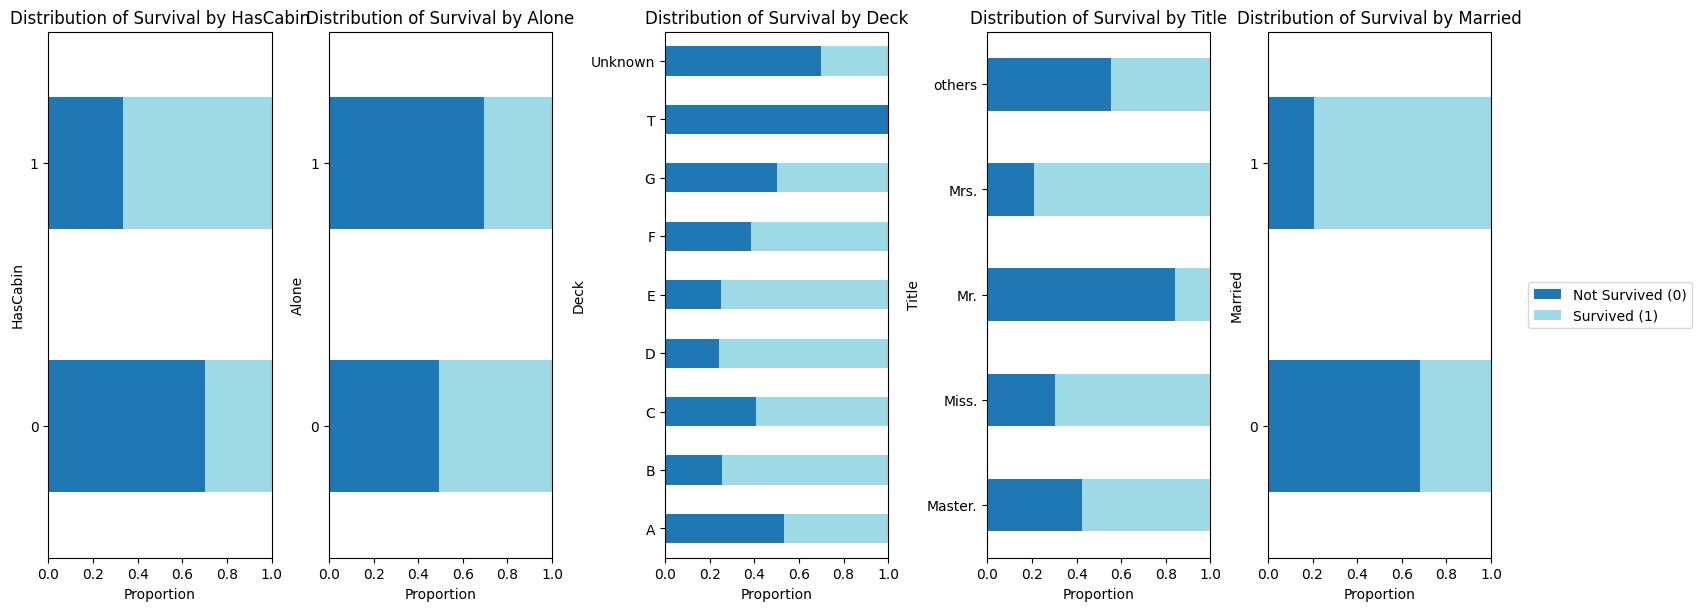

In [21]:
col_list = ['HasCabin', 'Alone', 'Deck', 'Title', 'Married']
plot_survival_distribution(X, col_list, y)

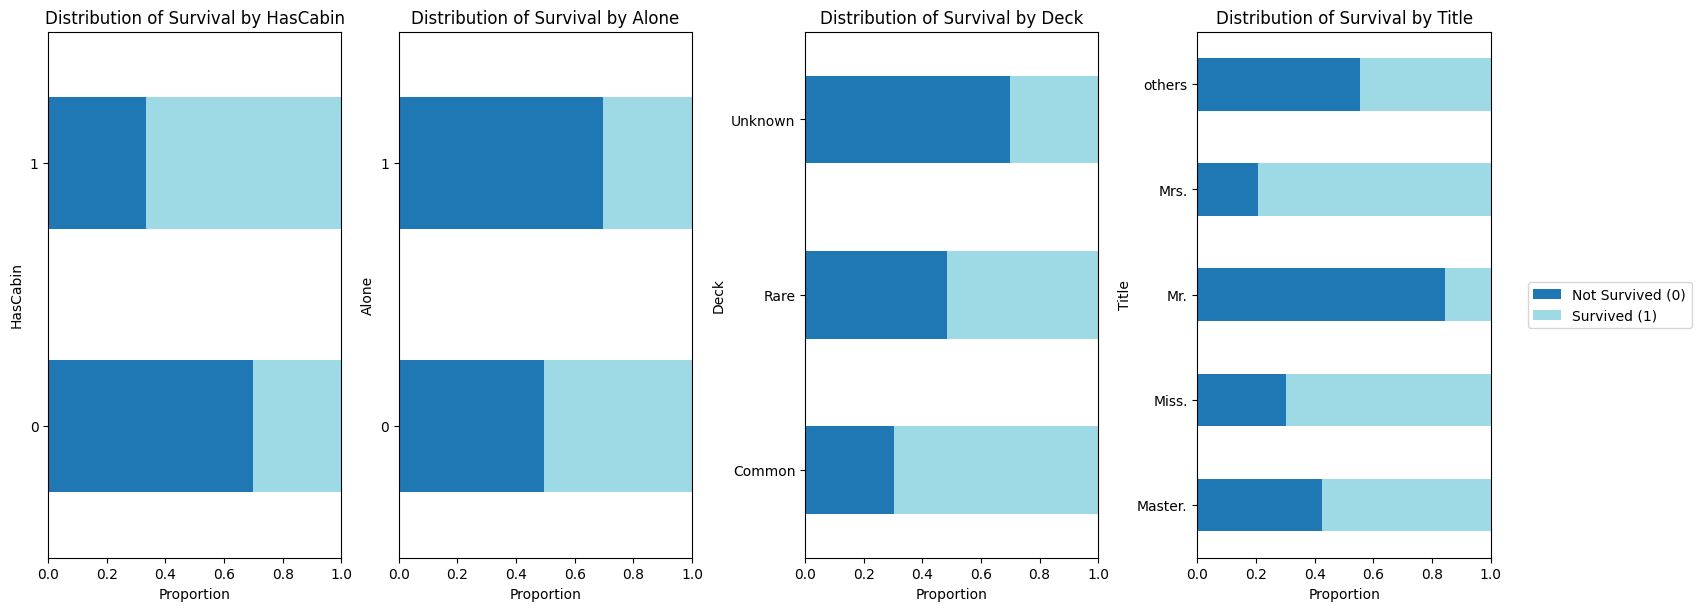

In [22]:
def deck_class(deck):
    if deck=='Unknown':
        return 'Unknown'
    elif deck in ['C', 'B', 'D', 'E']:
        return 'Common'
    else:
        return 'Rare'
    
X['Deck'] = X['Deck'].apply(deck_class)

col_list = ['HasCabin', 'Alone', 'Deck', 'Title']
plot_survival_distribution(X, col_list, y)


The crosstab analysis with engineered features shows strong signal on the survival rate.

## Data Preprocess

* Columns to drop: `Name`, `Cabin`, `Ticket`
* Boolean columns: `HasCabin`, `Alone`
* Numeral columns to be scaled: `Age`, `Fare`, `SibSp`, `Parch`, `Company`
* Categorical columns: `Sex`, `Pclass`, `Embarked`, `Title`, `Deck`

In [36]:
# create preprocess

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Company']
cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck']
bol_cols = ['HasCabin', 'Alone']

def create_new_preprocess():
    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
            ('bol', 'passthrough', bol_cols)
        ],
        remainder='drop'
    )
    return preprocess

In [37]:
preprocess = create_new_preprocess()
X_proc = preprocess.fit_transform(X)
feature_names = preprocess.get_feature_names_out()
X_proc_df = pd.DataFrame(X_proc, columns=feature_names)
X_proc_df.head()


,num__Age,num__Fare,num__SibSp,num__Parch,num__Company,cat__Sex_female,cat__Sex_male,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3,...,cat__Deck_B,cat__Deck_C,cat__Deck_D,cat__Deck_E,cat__Deck_F,cat__Deck_G,cat__Deck_T,cat__Deck_Unknown,bol__HasCabin,bol__Alone
0,-0.565736,-0.502445,0.432793,-0.473674,0.059160,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.663861,0.786845,0.432793,-0.473674,0.059160,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.258337,-0.488854,-0.474545,-0.473674,-0.560975,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.433312,0.420730,0.432793,-0.473674,0.059160,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.433312,-0.486337,-0.474545,-0.473674,-0.560975,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## Baseline Model Training with Engineered Data

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1 auc score (baseline / dummy): 0.8805 / 0.5000, acc score: 0.8101 / 0.6145
Baseline Model AUC/ACC Mean: 0.8805 ± 0.0000 / 0.8101 ± 0.0000


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 2 auc score (baseline / dummy): 0.8678 / 0.5000, acc score: 0.8034 / 0.6180
Baseline Model AUC/ACC Mean: 0.8741 ± 0.0064 / 0.8067 ± 0.0033


...

Fold 3 auc score (baseline / dummy): 0.8748 / 0.5000, acc score: 0.8202 / 0.6180
Baseline Model AUC/ACC Mean: 0.8744 ± 0.0052 / 0.8112 ± 0.0069


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 4 auc score (baseline / dummy): 0.8434 / 0.5000, acc score: 0.7921 / 0.6180
Baseline Model AUC/ACC Mean: 0.8666 ± 0.0141 / 0.8064 ± 0.0102


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 5 auc score (baseline / dummy): 0.8527 / 0.5000, acc score: 0.8146 / 0.6124
Baseline Model AUC/ACC Mean: 0.8639 ± 0.0138 / 0.8081 ± 0.0097
Dummy Model AUC/ACC Mean: 0.5000 ± 0.0000 / 0.6162 ± 0.0023
Baseline Model AUC/ACC Lift: 0.3639 / 0.1919


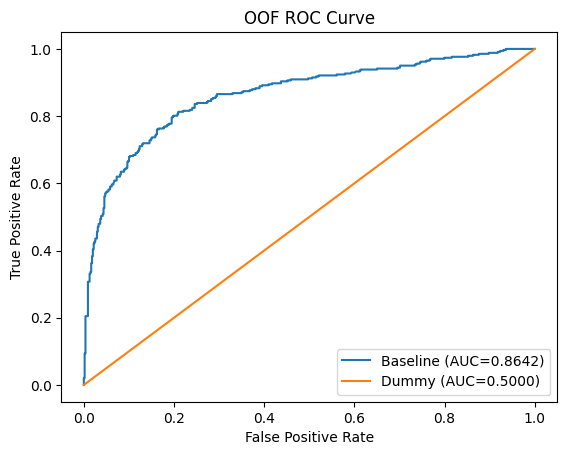

In [38]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)
batch_size = 64
epochs = 5
lr = 1e-2
weight_decay=0.0

perform_cv_baseline(X, y, skf, create_new_preprocess, DEVICE, batch_size, epochs, lr, weight_decay);

The first training result shows improvement on accuracy (0.77 to 0.80).

## Baseline Model Optimization

In [39]:
rng = np.random.default_rng(37)
best, history, best_model = random_search(rng, 20, cv_eval_fn, 'acc')


HPO trials:   0%|          | 0/20 [00:00<?, ?it/s]

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

...

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

In [40]:
for k, v in best.items():
    if v > 1e-3:
        print(f'{k}: {v:d}') if type(v) == int else print(f'{k}, {v:.4f}')
    else:
        print(f'{k}: {v:.4e}')
                

trial: 16
lr, 0.0885
weight_decay: 2.8927e-06
batch_size: 128
epochs: 20
mean, 0.8215
std, 0.0181


In [41]:

X_np = preprocess.transform(X)
X_tr = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)

params = best
lr = params['lr']
weight_decay = params['weight_decay']
batch_size = params['batch_size']
epochs = params['epochs']
loss_fn = nn.BCEWithLogitsLoss()
final_model = LogisticClass(X_np.shape[1]).to(DEVICE)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=lr, weight_decay=weight_decay)
metrics = {'acc': {'input_type': 'label', 'func': accuracy_score},
            'auc': {'input_type': 'prob', 'func': roc_auc_score}}
final_trainer = Trainer(final_model, final_optimizer, loss_fn, metrics, device=DEVICE)
final_trainer.train([X_np, y], batch_size=batch_size, epochs=epochs)

final_model.eval()
with torch.no_grad():
    logits = final_model(X_tr)
    prob = torch.sigmoid(logits).cpu().detach().numpy()
    y_pred = (prob >= 0.5).astype(int).squeeze()

Training:   0%|          | 0/20 [00:00<?, ?it/s]

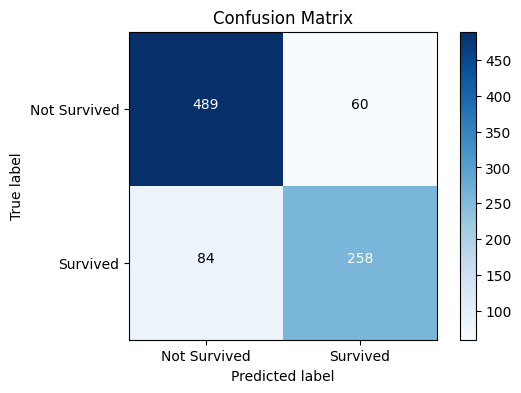

              precision    recall  f1-score   support

not survived       0.85      0.89      0.87       549
    survived       0.81      0.75      0.78       342

    accuracy                           0.84       891
   macro avg       0.83      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



In [42]:
plot_confusion_matrix_and_report(y, y_pred)

The evaluation result shows improvement over non-optimized model.

In [31]:
X_test_proc = add_fests(X_test)
X_test_np = preprocess.transform(X_test_proc)
X_test_ten = torch.tensor(X_test_np, dtype=torch.float32).to(DEVICE)

In [32]:
final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_ten)
    prob = torch.sigmoid(logits).cpu().detach().numpy()
    y_test_pred = (prob >= 0.5).astype(int).squeeze()

In [33]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_raw_df['PassengerId'],
    'Survived': y_test_pred
})

timestr = time.strftime("%Y%m%d-%H-%M-%S")

# Save to CSV
submission_df.to_csv(f'submission_{timestr}.csv', index=False)
print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.


## Improved Model


### XGBoost
Introduce a tree model `XGBoost` to see if there's any improvement.

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1 auc score (XGB / dummy): 0.8831 / 0.5000, acc score: 0.8212 / 0.6145, train auc/acc: 0.8984 / 0.8553
Fold 2 auc score (XGB / dummy): 0.8307 / 0.5000, acc score: 0.8034 / 0.6124, train auc/acc: 0.9119 / 0.8668
Fold 3 auc score (XGB / dummy): 0.8939 / 0.5000, acc score: 0.8315 / 0.6180, train auc/acc: 0.8996 / 0.8457
Fold 4 auc score (XGB / dummy): 0.8390 / 0.5000, acc score: 0.8090 / 0.6180, train auc/acc: 0.9131 / 0.8527
Fold 5 auc score (XGB / dummy): 0.8777 / 0.5000, acc score: 0.8427 / 0.6180, train auc/acc: 0.9065 / 0.8640
XGB Model AUC/ACC Mean: 0.8649 ± 0.0252 / 0.8215 ± 0.0144
XGB Model Train AUC/ACC Mean: 0.9059 ± 0.0061 / 0.8569 ± 0.0076
XGB Model Train/Val ACC Delta: 0.0354
Dummy Model AUC/ACC Mean: 0.5000 ± 0.0000 / 0.6162 ± 0.0023
XGB Model AUC/ACC Lift: 0.3649 / 0.2054


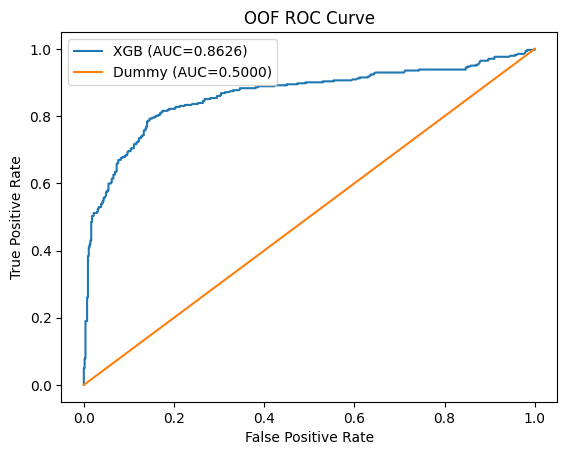

In [352]:
# XGBoost Model
from xgboost import XGBClassifier

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Company']
cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title']
bol_cols = ['HasCabin', 'Alone']

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            # scaler optional for XGBoost; harmless but usually not needed
            # ("scaler", StandardScaler()),
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),

        ("bol", "passthrough", bol_cols),
    ],
    remainder="drop",
)

def make_groups(df):
    surname = df["Name"].str.split(",", n=1).str[0].fillna("UNK")
    ticket = df["Ticket"].fillna("UNK")
    # You can try just ticket, just surname, or combined.
    return (surname + "_" + ticket).astype(str)

groups = make_groups(X)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    gamma=0.3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=8,
    reg_alpha=0.2,
    random_state=37,
    tree_method="hist",  # use "gpu_hist" if you have a supported GPU + build
    eval_metric="logloss",
)

pipe = Pipeline([
    ('fe', FunctionTransformer(add_fests, validate=False)),
    ("preprocess", preprocess),
    ("model", xgb_model),
])

dummy_model = DummyClassifier(strategy='most_frequent', random_state=37)
pipe_dummy = Pipeline([
    ('fe', FunctionTransformer(add_fests, validate=False)),
    ("preprocess", preprocess),
    ("model", dummy_model),
])

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)
# rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=37)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=37)
# pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")
pbar = tqdm(sgkf.split(X, y, groups=groups), total=sgkf.get_n_splits(), desc="CV folds")
auc_scores = []
acc_scores = []
dummy_acc_scores = []
dummy_auc_scores = []
oof_probs = []
oof_y_val = []
oof_dummy_probs = []

train_auc_scores = []
train_acc_scores = []

for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
    X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    pipe_fold = clone(pipe)
    pipe_fold.fit(X_tr_raw, y_tr)
    p = pipe_fold.predict_proba(X_val_raw)[:, 1]
    pred = (p >= 0.5).astype(int).squeeze()
    auc_score = roc_auc_score(y_val, p)
    acc_score = accuracy_score(y_val, pred)
    acc_scores.append(acc_score)
    auc_scores.append(auc_score)    
    oof_probs.append(p)
    oof_y_val.append(y_val)
    # train scores
    train_p = pipe_fold.predict_proba(X_tr_raw)[:, 1]
    train_pred = (train_p >= 0.5).astype(int).squeeze()
    train_auc_score = roc_auc_score(y_tr, train_p)
    train_acc_score = accuracy_score(y_tr, train_pred)
    train_auc_scores.append(train_auc_score)
    train_acc_scores.append(train_acc_score)
    # dummy model
    pipe_dummy.fit(X_tr_raw, y_tr)
    dummy_prob = pipe_dummy.predict_proba(X_val_raw)[:, 1]
    dummy_pred = (dummy_prob >= 0.5).astype(int).squeeze()    
    oof_dummy_probs.append(dummy_prob)
    dummy_acc_score = accuracy_score(y_val, dummy_pred)
    dummy_acc_scores.append(dummy_acc_score)
    dummy_auc_score = roc_auc_score(y_val, dummy_prob)
    dummy_auc_scores.append(dummy_auc_score)
    tqdm.write(f"Fold {fold} auc score (XGB / dummy): {auc_score:.4f} / {dummy_auc_score:.4f}, acc score: {acc_score:.4f} / {dummy_acc_score:.4f}, train auc/acc: {train_auc_score:.4f} / {train_acc_score:.4f}")

print(f"XGB Model AUC/ACC Mean: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f} / {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"XGB Model Train AUC/ACC Mean: {np.mean(train_auc_scores):.4f} ± {np.std(train_auc_scores):.4f} / {np.mean(train_acc_scores):.4f} ± {np.std(train_acc_scores):.4f}")
print(f'XGB Model Train/Val ACC Delta: {(np.mean(train_acc_scores) - np.mean(acc_scores)):.4f}')

print(f"Dummy Model AUC/ACC Mean: {np.mean(dummy_auc_scores):.4f} ± {np.std(dummy_auc_scores):.4f} / {np.mean(dummy_acc_scores):.4f} ± {np.std(dummy_acc_scores):.4f}")
print(f'XGB Model AUC/ACC Lift: {(np.mean(auc_scores) - np.mean(dummy_auc_scores)):.4f} / {(np.mean(acc_scores) - np.mean(dummy_acc_scores)):.4f}')


plt.figure()
oof_probs = np.concatenate(oof_probs)
oof_y_val = np.concatenate(oof_y_val)
auc = roc_auc_score(oof_y_val, oof_probs)
fpr, tpr, thr = roc_curve(oof_y_val, oof_probs)
plt.plot(fpr, tpr, label=f'XGB (AUC={auc:.4f})')
oof_dummy_probs = np.concatenate(oof_dummy_probs)
dummy_auc = roc_auc_score(oof_y_val, oof_dummy_probs)
fpr, tpr, thr = roc_curve(oof_y_val, oof_dummy_probs)
plt.plot(fpr, tpr, label=f'Dummy (AUC={dummy_auc:.4f})')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"OOF ROC Curve")
plt.legend()
plt.show()


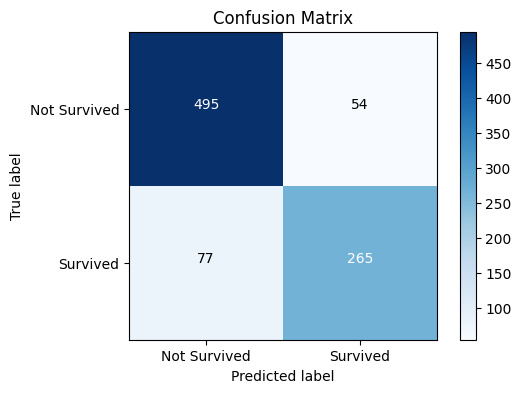

              precision    recall  f1-score   support

not survived       0.87      0.90      0.88       549
    survived       0.83      0.77      0.80       342

    accuracy                           0.85       891
   macro avg       0.85      0.84      0.84       891
weighted avg       0.85      0.85      0.85       891



In [353]:
pipe_train = clone(pipe)
pipe_train.fit(X, y)
p = pipe_train.predict_proba(X)[:, 1]
y_pred = (p >= 0.5).astype(int).squeeze()
plot_confusion_matrix_and_report(y, y_pred)


The initial result with XGB shows significant improvement over baseline model.

In [338]:
# All comments in English as requested.
test_p_sum = np.zeros(len(X_test), dtype=float)
fold_models = 0

for tr_idx, val_idx in sgkf.split(X, y, groups=groups):
    X_tr = X.iloc[tr_idx]
    y_tr = y[tr_idx]

    pipe_fold.fit(X_tr, y_tr)
    test_p_sum += pipe_fold.predict_proba(X_test)[:, 1]
    fold_models += 1

test_p = test_p_sum / fold_models
y_test_pred = (test_p >= best_t).astype(int)

len(y_test_pred[y_test_pred==1]) / len(y_test_pred)

0.3660287081339713

In [354]:
test_p = pipe_train.predict(X_test)
y_test_pred = (test_p >= 0.5).astype(int)
len(y_test_pred[y_test_pred==1]) / len(y_test_pred)

0.37559808612440193

In [349]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_raw_df['PassengerId'],
    'Survived': y_test_pred
})

timestr = time.strftime("%Y%m%d-%H-%M-%S")

# Save to CSV
submission_df.to_csv(f'submission_{timestr}.csv', index=False)
print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.


In [292]:
def cv_eval_fn_xgb(params, score_type):
    n_estimators = params['n_estimators']
    learning_rate = params['learning_rate']
    max_depth = params['max_depth']
    subsample = params['subsample']
    colsample_bytree = params['colsample_bytree']
    reg_lambda = params['reg_lambda']
    
    # # Define preprocess for XGBoost (similar to CELL INDEX: 28)
    # num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Company']
    # cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck']
    # bol_cols = ['HasCabin', 'Alone']
    
    # preprocess = ColumnTransformer(
    #     transformers=[
    #         ("num", Pipeline([
    #             ("imputer", SimpleImputer(strategy="median")),
    #             # No scaler for XGBoost
    #         ]), num_cols),
    #         ("cat", Pipeline([
    #             ("imputer", SimpleImputer(strategy="most_frequent")),
    #             ("onehot", OneHotEncoder(handle_unknown="ignore")),
    #         ]), cat_cols),
    #         ("bol", "passthrough", bol_cols),
    #     ],
    #     remainder="drop",
    # )
    
    xgb_model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=params['min_child_weight'],
        gamma=params['gamma'],
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=params['reg_alpha'],
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
    )
    
    pipe = Pipeline([
        ('fe', FunctionTransformer(add_fests, validate=False)),
        ("preprocess", preprocess),
        ("model", xgb_model),
    ])
    
    acc_scores = []
    auc_scores = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        pipe.fit(X_tr_raw, y_tr)
        p = pipe.predict_proba(X_val_raw)[:, 1]
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)
    
    if score_type == 'acc':
        mean_score = np.mean(acc_scores)
        std_score = np.std(acc_scores)
    elif score_type == 'auc':
        mean_score = np.mean(auc_scores)
        std_score = np.std(auc_scores)
    else:
        raise ValueError(f"Invalid score_type '{score_type}'. Must be 'acc' or 'auc'.")
    
    return mean_score, std_score, pipe.named_steps['model']


# Hyperparameter optimization for XGBoost
def sample_params_xgb(rng: np.random.Generator) -> dict:
    """Randomly sample a hyperparameter configuration for XGBoost."""
    # return {
    #     "n_estimators": int(rng.choice([100, 200, 300, 400, 500])),
    #     "learning_rate": log_uniform(rng, 1e-3, 1e-1),
    #     "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
    #     "subsample": rng.uniform(0.6, 1.0),
    #     "colsample_bytree": rng.uniform(0.6, 1.0),
    #     "reg_lambda": log_uniform(rng, 1e-3, 1e1),
    # }
    return {
        "n_estimators": int(rng.choice([400, 600, 800, 1000, 1200])),
        "learning_rate": log_uniform(rng, 0.01, 0.08),

        "max_depth": int(rng.choice([2, 3, 4])),
        "min_child_weight": log_uniform(rng, 1.0, 20.0),
        "gamma": log_uniform(rng, 1e-3, 2.0),

        "subsample": rng.uniform(0.6, 1.0),
        "colsample_bytree": rng.uniform(0.6, 1.0),

        "reg_lambda": log_uniform(rng, 1.0, 50.0),
        "reg_alpha": log_uniform(rng, 1e-4, 2.0),
    }
    
def random_search_xgb(rng: np.random.Generator, n_trials: int, cv_eval_fn, score_type):
    """
    cv_eval_fn(params) -> (mean_score, std_score, model)
    """
    best = None
    best_model = None
    history = []
    pbar = tqdm(range(n_trials), desc="XGBoost HPO trials")
    for t in pbar:
        params = sample_params_xgb(rng)
        mean_score, std_score, model = cv_eval_fn(params, score_type)

        record = {"trial": t, **params, "mean": mean_score, "std": std_score}
        history.append(record)

        # simple selection rule: prefer high mean, break ties by low std
        if (best is None) or (mean_score > best["mean"]) or (
            mean_score == best["mean"] and std_score < best["std"]
        ):
            best = record
            best_model = model
        pbar.set_postfix(best_mean=f"{best['mean']:.4f}", lr=f"{best['learning_rate']:.2e}", n_est=f"{best['n_estimators']}")

    return best, history, best_model


In [256]:

# Run HPO for XGBoost
best_xgb, history_xgb, best_xgb_model = random_search_xgb(rng, 20, cv_eval_fn_xgb, 'acc')

# Print best parameters
print("Best XGBoost Hyperparameters:")
for k, v in best_xgb.items():
    if v > 1e-3:
        print(f'{k}: {v:d}') if type(v) == int else print(f'{k}: {v:.4f}')
    else:
        print(f'{k}: {v:.4e}')

XGBoost HPO trials:   0%|          | 0/20 [00:00<?, ?it/s]

Best XGBoost Hyperparameters:
trial: 14
n_estimators: 400
learning_rate: 0.0741
max_depth: 2
min_child_weight: 1.4564
gamma: 0.1771
subsample: 0.9938
colsample_bytree: 0.7308
reg_lambda: 2.8962
reg_alpha: 0.0228
mean: 0.8373
std: 0.0211


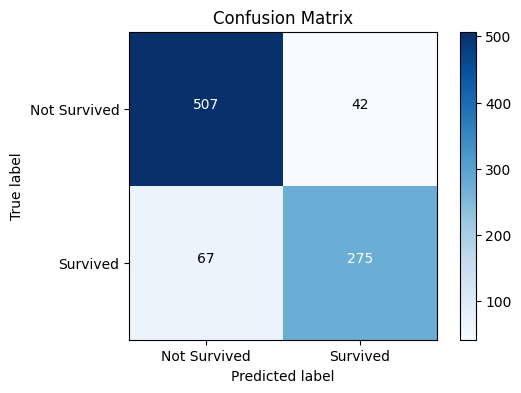

              precision    recall  f1-score   support

not survived       0.88      0.92      0.90       549
    survived       0.87      0.80      0.83       342

    accuracy                           0.88       891
   macro avg       0.88      0.86      0.87       891
weighted avg       0.88      0.88      0.88       891



In [ ]:

best_params = {
    k: v for k, v in best_xgb.items()
    if k in {"n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "reg_lambda"}
}

best_model = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=37,
    n_jobs=-1,
)

# num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Company']
# cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck']
# bol_cols = ['HasCabin', 'Alone']

# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", Pipeline([
#             ("imputer", SimpleImputer(strategy="median")),
#             # No scaler for XGBoost
#         ]), num_cols),
#         ("cat", Pipeline([
#             ("imputer", SimpleImputer(strategy="most_frequent")),
#             ("onehot", OneHotEncoder(handle_unknown="ignore")),
#         ]), cat_cols),
#         ("bol", "passthrough", bol_cols),
#     ],
#     remainder="drop",
# )

best_pipe = Pipeline([
    ('fe', FunctionTransformer(add_fests, validate=False)),
    ("preprocess", preprocess),
    ("model", best_model),
])
best_pipe.fit(X, y)
prob = best_pipe.predict_proba(X)[:, 1]
y_pred = (prob >= 0.5).astype(int).squeeze()
plot_confusion_matrix_and_report(y, y_pred)

In [266]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import clone
import numpy as np

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=37)

accs = []
for tr_idx, val_idx in rskf.split(X, y):
    m = clone(best_pipe)                 # important: fresh pipe each fold
    m.fit(X.iloc[tr_idx], y[tr_idx])
    p = m.predict_proba(X.iloc[val_idx])[:, 1]
    pred = (p >= 0.5).astype(int)
    accs.append((pred == y[val_idx]).mean())

print(np.mean(accs), np.std(accs))


0.8314456091896304 0.029968426474729633


In [261]:
from sklearn.base import clone
import numpy as np

oof_p = np.zeros(len(X), dtype=float)

for tr_idx, val_idx in skf.split(X, y):
    m = clone(best_pipe)
    m.fit(X.iloc[tr_idx], y[tr_idx])
    oof_p[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

# Find threshold that maximizes OOF accuracy
ths = np.linspace(0.05, 0.95, 181)
acc = [( (oof_p >= t).astype(int) == y ).mean() for t in ths]
best_t = ths[int(np.argmax(acc))]
print("Best OOF threshold:", best_t, "OOF acc:", max(acc))


Best OOF threshold: 0.49499999999999994 OOF acc: 0.8383838383838383


With optimized hyperparameters the result is even better with >0.9 precision in both cases.

In [258]:
test_raw_df = pd.read_csv(test_data_path)
X_test = test_raw_df


In [274]:
prob = pipe.predict_proba(X_test)[:, 1]
y_test_pred = (prob >= 0.5).astype(int).squeeze()

In [275]:

# Create submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_raw_df['PassengerId'],
    'Survived': y_test_pred
})

timestr = time.strftime("%Y%m%d-%H-%M-%S")

# Save to CSV
submission_df.to_csv(f'submission_{timestr}.csv', index=False)
print("Submission file 'submission.csv' created.")


Submission file 'submission.csv' created.


However, the submitted prediction on test data shows only 0.75 accuracy. It suggests that current model may be over-fitted to the train data...